In [44]:
#===========================
#
#
#
# MLOps Project
#
# Pablo Rodriguez
#


In [45]:
import hashlib
import json
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
CONFIG = {
    "project": "prompt_ab_testing_demo",
    "experiment": "occupation_prompt_v1_vs_v2",
    "random_seed": 42,

    # 50% of subjects → A, remainder → B
    "traffic_split": 0.50,

    # Release guardrails
    "minimum_quality_gain": 0.02,
    "maximum_cost_increase": 0.20,
    "maximum_latency_increase": 0.25,

    # Demo pricing only — not real provider pricing
    "cost_per_1k_tokens": 0.002
}

ARTIFACT_DIR = Path("prompt_ab_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

CONFIG

{'project': 'prompt_ab_testing_demo',
 'experiment': 'occupation_prompt_v1_vs_v2',
 'random_seed': 42,
 'traffic_split': 0.5,
 'minimum_quality_gain': 0.02,
 'maximum_cost_increase': 0.2,
 'maximum_latency_increase': 0.25,
 'cost_per_1k_tokens': 0.002}

In [47]:
prompt_registry = []

In [48]:
def register_prompt(
    name,
    version,
    template,
    variant,
    status
):
    if any(
        prompt["name"] == name
        and prompt["version"] == version
        for prompt in prompt_registry
    ):
        raise ValueError(
            f"{name} version {version} already exists."
        )

    prompt_id = hashlib.sha256(
        f"{name}:{version}:{template}".encode()
    ).hexdigest()[:12]

    record = {
        "prompt_id": prompt_id,
        "name": name,
        "version": version,
        "variant": variant,
        "status": status,
        "template": template,
        "created_at": datetime.now(
            timezone.utc
        ).isoformat()
    }

    prompt_registry.append(record)

    return record

In [49]:
PROMPT_A = register_prompt(
    name="occupation_classifier",
    version="1.0.0",
    variant="A",
    status="champion",
    template="""
Classify the worker description into the best occupation.

Description:
{query}

Return the occupation name.
""".strip()
)

PROMPT_A

{'prompt_id': '7bcdce035406',
 'name': 'occupation_classifier',
 'version': '1.0.0',
 'variant': 'A',
 'status': 'champion',
 'template': 'Classify the worker description into the best occupation.\n\nDescription:\n{query}\n\nReturn the occupation name.',
 'created_at': '2026-09-27T04:38:34.129421+00:00'}

In [50]:
PROMPT_B = register_prompt(
    name="occupation_classifier",
    version="2.0.0",
    variant="B",
    status="challenger",
    template="""
You are an occupation classification assistant.

Read the worker description carefully and identify
the worker's primary duties.

Worker description:
{query}

Select the occupation that best matches those duties.

Return only the occupation name.
""".strip()
)

PROMPT_B

{'prompt_id': '63d2431aad3c',
 'name': 'occupation_classifier',
 'version': '2.0.0',
 'variant': 'B',
 'status': 'challenger',
 'template': "You are an occupation classification assistant.\n\nRead the worker description carefully and identify\nthe worker's primary duties.\n\nWorker description:\n{query}\n\nSelect the occupation that best matches those duties.\n\nReturn only the occupation name.",
 'created_at': '2026-09-27T04:38:34.142921+00:00'}

In [51]:
registry_df = pd.DataFrame(
    prompt_registry
)

registry_df[
    [
        "prompt_id",
        "name",
        "version",
        "variant",
        "status",
        "created_at"
    ]
]

,prompt_id,name,version,variant,status,created_at
0,7bcdce035406,occupation_classifier,1.0.0,A,champion,2026-09-27T04:38:34.129421+00:00
1,63d2431aad3c,occupation_classifier,2.0.0,B,challenger,2026-09-27T04:38:34.142921+00:00


In [52]:
def get_prompt(name, version):

    for prompt in prompt_registry:

        if (
            prompt["name"] == name
            and prompt["version"] == version
        ):
            return prompt

    raise KeyError(
        f"Prompt {name} {version} not found."
    )

In [53]:
golden_data = pd.DataFrame([
    {
        "query":
            "I install and repair electrical wiring in homes.",
        "expected":
            "Electrician"
    },
    {
        "query":
            "I provide care to patients in a hospital.",
        "expected":
            "Registered Nurse"
    },
    {
        "query":
            "I build and maintain computer applications.",
        "expected":
            "Software Developer"
    },
    {
        "query":
            "I teach children in a classroom.",
        "expected":
            "Teacher"
    },
    {
        "query":
            "I build wooden cabinets and structures.",
        "expected":
            "Carpenter"
    },
    {
        "query":
            "I prepare financial statements and tax records.",
        "expected":
            "Accountant"
    },
    {
        "query":
            "I install and repair water pipes.",
        "expected":
            "Plumber"
    },
    {
        "query":
            "I prepare meals in a restaurant.",
        "expected":
            "Cook"
    },
    {
        "query":
            "I analyze company data and prepare reports.",
        "expected":
            "Data Analyst"
    },
    {
        "query":
            "I recruit employees and manage personnel records.",
        "expected":
            "Human Resources Specialist"
    },
    {
        "query":
            "I design and test mechanical machines.",
        "expected":
            "Mechanical Engineer"
    },
    {
        "query":
            "I supervise construction projects and budgets.",
        "expected":
            "Construction Manager"
    }
])

golden_data

,query,expected
0,I install and repair electrical wiring in homes.,Electrician
1,I provide care to patients in a hospital.,Registered Nurse
2,I build and maintain computer applications.,Software Developer
3,I teach children in a classroom.,Teacher
4,I build wooden cabinets and structures.,Carpenter
5,I prepare financial statements and tax records.,Accountant
6,I install and repair water pipes.,Plumber
7,I prepare meals in a restaurant.,Cook
8,I analyze company data and prepare reports.,Data Analyst
9,I recruit employees and manage personnel records.,Human Resources Specialist


In [54]:
def render_prompt(
    prompt_record,
    query
):
    return prompt_record[
        "template"
    ].format(
        query=query
    )

In [55]:
def assign_variant(subject_id):

    digest = hashlib.sha256(
        str(subject_id).encode()
    ).hexdigest()

    bucket = (
        int(digest[:8], 16)
        / 0xFFFFFFFF
    )

    if bucket < CONFIG["traffic_split"]:
        return "A"

    return "B"

In [56]:
KEYWORD_RULES = {
    "electrical": "Electrician",
    "patients": "Registered Nurse",
    "computer": "Software Developer",
    "teach": "Teacher",
    "wooden": "Carpenter",
    "financial": "Accountant",
    "pipes": "Plumber",
    "meals": "Cook",
    "data": "Data Analyst",
    "recruit": "Human Resources Specialist",
    "mechanical": "Mechanical Engineer",
    "construction": "Construction Manager"
}

In [57]:
def deterministic_number(*values):

    text = "|".join(
        str(value)
        for value in values
    )

    digest = hashlib.sha256(
        text.encode()
    ).hexdigest()

    return (
        int(digest[:8], 16)
        / 0xFFFFFFFF
    )

In [58]:
def mock_llm(
    query,
    variant,
    subject_id
):

    query_lower = query.lower()

    prediction = "Unknown"

    for keyword, occupation in KEYWORD_RULES.items():

        if keyword in query_lower:
            prediction = occupation
            break

    # Variant B is simulated as the stronger prompt.
    error_rate = (
        0.18
        if variant == "A"
        else 0.07
    )

    error_number = deterministic_number(
        query,
        variant,
        subject_id,
        "error"
    )

    if (
        prediction != "Unknown"
        and error_number < error_rate
    ):

        choices = sorted(
            KEYWORD_RULES.values()
        )

        wrong_choices = [
            occupation
            for occupation in choices
            if occupation != prediction
        ]

        choice_number = deterministic_number(
            query,
            variant,
            subject_id,
            "wrong_choice"
        )

        index = int(
            choice_number
            * len(wrong_choices)
        )

        index = min(
            index,
            len(wrong_choices) - 1
        )

        prediction = wrong_choices[
            index
        ]

    # Synthetic latency — no unnecessary sleep().
    latency_number = deterministic_number(
        query,
        variant,
        subject_id,
        "latency"
    )

    if variant == "A":

        latency_ms = (
            25
            + latency_number * 20
        )

    else:

        latency_ms = (
            30
            + latency_number * 20
        )

    return (
        prediction,
        float(latency_ms)
    )

In [59]:
def estimate_tokens(text):

    # Educational approximation:
    # roughly 1 token per 4 characters.

    return max(
        1,
        len(text) // 4
    )

In [60]:
def estimate_cost(
    prompt,
    response
):

    tokens = (
        estimate_tokens(prompt)
        +
        estimate_tokens(response)
    )

    cost = (
        tokens
        / 1000
        * CONFIG["cost_per_1k_tokens"]
    )

    return (
        tokens,
        cost
    )

In [61]:
experiment_logs = []

In [62]:
def run_request(
    subject_id,
    query,
    expected
):

    variant = assign_variant(
        subject_id
    )

    prompt_record = (
        PROMPT_A
        if variant == "A"
        else PROMPT_B
    )

    rendered_prompt = render_prompt(
        prompt_record,
        query
    )

    prediction, latency_ms = mock_llm(
        query,
        variant,
        subject_id
    )

    tokens, cost = estimate_cost(
        rendered_prompt,
        prediction
    )

    correct = (
        prediction == expected
    )

    log = {
        "timestamp":
            datetime.now(
                timezone.utc
            ).isoformat(),

        "experiment":
            CONFIG["experiment"],

        "subject_id":
            subject_id,

        "variant":
            variant,

        "prompt_version":
            prompt_record["version"],

        "prompt_id":
            prompt_record["prompt_id"],

        "query":
            query,

        "expected":
            expected,

        "prediction":
            prediction,

        "correct":
            correct,

        "tokens":
            tokens,

        "cost":
            cost,

        "latency_ms":
            latency_ms
    }

    experiment_logs.append(
        log
    )

    return log

In [63]:
REQUESTS = 240

for request_id in range(
    REQUESTS
):

    example = golden_data.iloc[
        request_id
        % len(golden_data)
    ]

    run_request(
        subject_id=request_id,
        query=example["query"],
        expected=example["expected"]
    )


logs_df = pd.DataFrame(
    experiment_logs
)

logs_df.head()

,timestamp,experiment,subject_id,variant,prompt_version,prompt_id,query,expected,prediction,correct,tokens,cost,latency_ms
0,2026-09-27T04:38:34.293133+00:00,occupation_prompt_v1_vs_v2,0,A,1.0.0,7bcdce035406,I install and repair electrical wiring in homes.,Electrician,Accountant,False,39,0.000078,40.703238
1,2026-09-27T04:38:34.293252+00:00,occupation_prompt_v1_vs_v2,1,A,1.0.0,7bcdce035406,I provide care to patients in a hospital.,Registered Nurse,Registered Nurse,True,39,0.000078,39.590273
2,2026-09-27T04:38:34.293323+00:00,occupation_prompt_v1_vs_v2,2,B,2.0.0,63d2431aad3c,I build and maintain computer applications.,Software Developer,Software Developer,True,74,0.000148,33.895925
3,2026-09-27T04:38:34.293385+00:00,occupation_prompt_v1_vs_v2,3,A,1.0.0,7bcdce035406,I teach children in a classroom.,Teacher,Teacher,True,34,0.000068,43.153670
4,2026-09-27T04:38:34.293443+00:00,occupation_prompt_v1_vs_v2,4,A,1.0.0,7bcdce035406,I build wooden cabinets and structures.,Carpenter,Carpenter,True,37,0.000074,39.149001


In [64]:
traffic_split = (
    logs_df["variant"]
    .value_counts(
        normalize=True
    )
    .sort_index()
)

traffic_split

,proportion
variant,
A,0.545833
B,0.454167


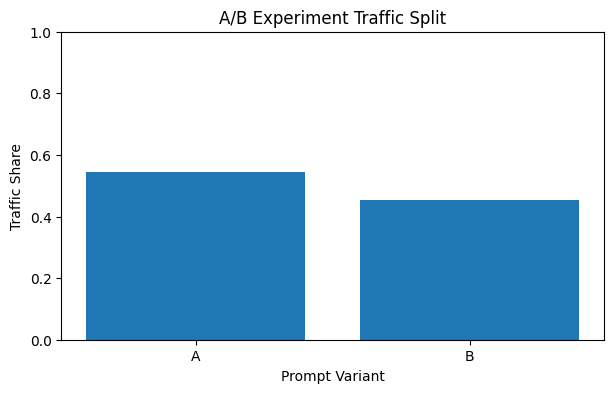

In [65]:
plt.figure(
    figsize=(7, 4)
)

plt.bar(
    traffic_split.index,
    traffic_split.values
)

plt.ylim(
    0,
    1
)

plt.xlabel(
    "Prompt Variant"
)

plt.ylabel(
    "Traffic Share"
)

plt.title(
    "A/B Experiment Traffic Split"
)

plt.show()

In [66]:
experiment_summary = (
    logs_df
    .groupby(
        [
            "variant",
            "prompt_version"
        ]
    )
    .agg(
        requests=(
            "correct",
            "count"
        ),

        accuracy=(
            "correct",
            "mean"
        ),

        avg_tokens=(
            "tokens",
            "mean"
        ),

        avg_cost=(
            "cost",
            "mean"
        ),

        total_cost=(
            "cost",
            "sum"
        ),

        avg_latency_ms=(
            "latency_ms",
            "mean"
        )
    )
    .reset_index()
)

experiment_summary

,variant,prompt_version,requests,accuracy,avg_tokens,avg_cost,total_cost,avg_latency_ms
0,A,1.0.0,131,0.832061,37.961832,0.000076,0.009946,34.788425
1,B,2.0.0,109,0.954128,72.394495,0.000145,0.015782,39.153301


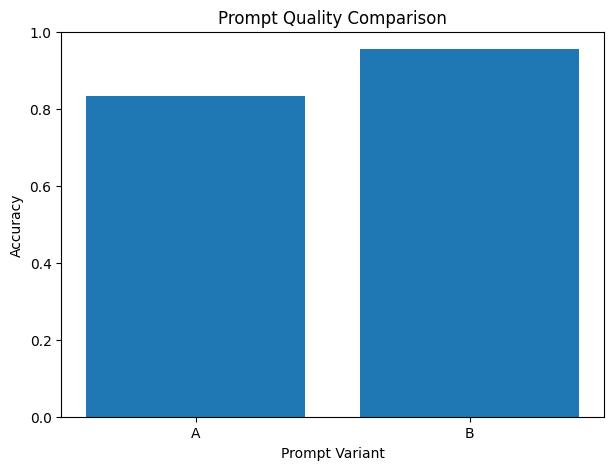

In [67]:
quality = (
    experiment_summary
    .set_index("variant")[
        "accuracy"
    ]
)

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    quality.index,
    quality.values
)

plt.ylim(
    0,
    1
)

plt.xlabel(
    "Prompt Variant"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Prompt Quality Comparison"
)

plt.show()

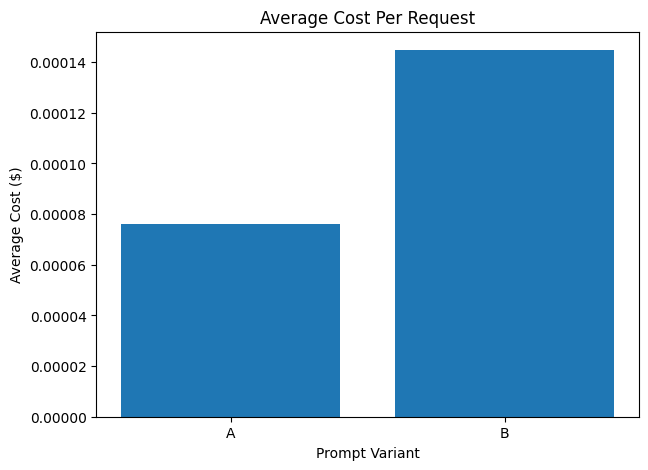

In [68]:
cost = (
    experiment_summary
    .set_index("variant")[
        "avg_cost"
    ]
)

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    cost.index,
    cost.values
)

plt.xlabel(
    "Prompt Variant"
)

plt.ylabel(
    "Average Cost ($)"
)

plt.title(
    "Average Cost Per Request"
)

plt.show()

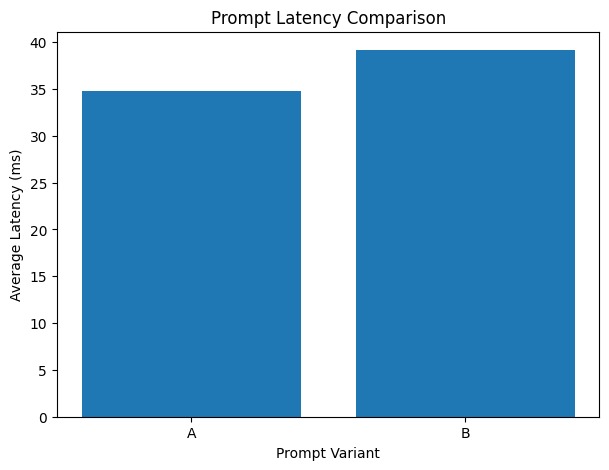

In [69]:
latency = (
    experiment_summary
    .set_index("variant")[
        "avg_latency_ms"
    ]
)

plt.figure(
    figsize=(7, 5)
)

plt.bar(
    latency.index,
    latency.values
)

plt.xlabel(
    "Prompt Variant"
)

plt.ylabel(
    "Average Latency (ms)"
)

plt.title(
    "Prompt Latency Comparison"
)

plt.show()

In [70]:
def bootstrap_accuracy_difference(
    dataframe,
    samples=1000,
    seed=42
):

    rng = np.random.default_rng(
        seed
    )

    a_values = dataframe[
        dataframe["variant"] == "A"
    ]["correct"].astype(int).to_numpy()

    b_values = dataframe[
        dataframe["variant"] == "B"
    ]["correct"].astype(int).to_numpy()

    differences = np.empty(
        samples
    )

    for index in range(samples):

        a_sample = rng.choice(
            a_values,
            size=len(a_values),
            replace=True
        )

        b_sample = rng.choice(
            b_values,
            size=len(b_values),
            replace=True
        )

        differences[index] = (
            b_sample.mean()
            -
            a_sample.mean()
        )

    return {
        "mean_difference":
            float(
                differences.mean()
            ),

        "lower_95":
            float(
                np.percentile(
                    differences,
                    2.5
                )
            ),

        "upper_95":
            float(
                np.percentile(
                    differences,
                    97.5
                )
            )
    }

In [71]:
bootstrap_result = (
    bootstrap_accuracy_difference(
        logs_df
    )
)

bootstrap_result

{'mean_difference': 0.1220346662931578,
 'lower_95': 0.04874290916730861,
 'upper_95': 0.20302542194831574}

In [72]:
summary = (
    experiment_summary
    .set_index("variant")
)

a = summary.loc["A"]
b = summary.loc["B"]

quality_gain = (
    b["accuracy"]
    -
    a["accuracy"]
)

cost_change = (
    b["avg_cost"]
    -
    a["avg_cost"]
) / a["avg_cost"]

latency_change = (
    b["avg_latency_ms"]
    -
    a["avg_latency_ms"]
) / a["avg_latency_ms"]


print(
    f"Quality gain: {quality_gain:.2%}"
)

print(
    f"Cost change: {cost_change:.2%}"
)

print(
    f"Latency change: {latency_change:.2%}"
)

Quality gain: 12.21%
Cost change: 90.70%
Latency change: 12.55%


In [73]:
quality_pass = (
    quality_gain
    >= CONFIG[
        "minimum_quality_gain"
    ]
)

cost_pass = (
    cost_change
    <= CONFIG[
        "maximum_cost_increase"
    ]
)

latency_pass = (
    latency_change
    <= CONFIG[
        "maximum_latency_increase"
    ]
)

promotion_passed = (
    quality_pass
    and cost_pass
    and latency_pass
)

decision = (
    "PROMOTE_B"
    if promotion_passed
    else "KEEP_A"
)


print(
    "=" * 50
)

print(
    "PROMPT RELEASE GATE"
)

print(
    "=" * 50
)

print(
    "Quality:",
    "PASS"
    if quality_pass
    else "FAIL"
)

print(
    "Cost:",
    "PASS"
    if cost_pass
    else "FAIL"
)

print(
    "Latency:",
    "PASS"
    if latency_pass
    else "FAIL"
)

print()

print(
    "FINAL DECISION:",
    decision
)

PROMPT RELEASE GATE
Quality: PASS
Cost: FAIL
Latency: PASS

FINAL DECISION: KEEP_A


In [74]:
error_summary = (
    logs_df[
        ~logs_df["correct"]
    ]
    .groupby(
        [
            "variant",
            "expected",
            "prediction"
        ]
    )
    .size()
    .reset_index(
        name="errors"
    )
    .sort_values(
        "errors",
        ascending=False
    )
)

error_summary.head(
    20
)

,variant,expected,prediction,errors
1,A,Accountant,Mechanical Engineer,2
12,A,Human Resources Specialist,Construction Manager,2
0,A,Accountant,Construction Manager,1
3,A,Carpenter,Teacher,1
2,A,Carpenter,Electrician,1
5,A,Construction Manager,Plumber,1
6,A,Construction Manager,Registered Nurse,1
7,A,Cook,Accountant,1
4,A,Construction Manager,Electrician,1
8,A,Cook,Electrician,1


In [75]:
task_accuracy = (
    logs_df
    .groupby(
        [
            "variant",
            "expected"
        ]
    )["correct"]
    .mean()
    .unstack(
        fill_value=0
    )
)

task_accuracy

expected,Accountant,Carpenter,Construction Manager,Cook,Data Analyst,Electrician,Human Resources Specialist,Mechanical Engineer,Plumber,Registered Nurse,Software Developer,Teacher
variant,,,,,,,,,,,,
A,0.75,0.75,0.769231,0.846154,1.000000,0.727273,0.833333,0.777778,0.923077,0.777778,0.833333,1.0
B,1.00,1.00,1.000000,1.000000,0.818182,1.000000,0.875000,1.000000,1.000000,0.909091,1.000000,0.9


In [76]:
regression_analysis = pd.DataFrame({
    "A_accuracy":
        task_accuracy.loc["A"],

    "B_accuracy":
        task_accuracy.loc["B"]
})

regression_analysis[
    "difference"
] = (
    regression_analysis[
        "B_accuracy"
    ]
    -
    regression_analysis[
        "A_accuracy"
    ]
)

regression_analysis.sort_values(
    "difference"
)

,A_accuracy,B_accuracy,difference
expected,,,
Data Analyst,1.000000,0.818182,-0.181818
Teacher,1.000000,0.900000,-0.100000
Human Resources Specialist,0.833333,0.875000,0.041667
Plumber,0.923077,1.000000,0.076923
Registered Nurse,0.777778,0.909091,0.131313
Cook,0.846154,1.000000,0.153846
Software Developer,0.833333,1.000000,0.166667
Mechanical Engineer,0.777778,1.000000,0.222222
Construction Manager,0.769231,1.000000,0.230769


In [77]:
ACTIVE_PROMPT = (
    PROMPT_B
    if decision == "PROMOTE_B"
    else PROMPT_A
)

print(
    "Active prompt version:",
    ACTIVE_PROMPT["version"]
)

Active prompt version: 1.0.0


In [78]:
def rollback():

    global ACTIVE_PROMPT

    ACTIVE_PROMPT = PROMPT_A

In [79]:
def run_active_prompt(
    query,
    subject_id="production-demo"
):

    rendered_prompt = render_prompt(
        ACTIVE_PROMPT,
        query
    )

    prediction, latency_ms = mock_llm(
        query,
        ACTIVE_PROMPT["variant"],
        subject_id
    )

    tokens, cost = estimate_cost(
        rendered_prompt,
        prediction
    )

    return {
        "prompt_id":
            ACTIVE_PROMPT[
                "prompt_id"
            ],

        "prompt_version":
            ACTIVE_PROMPT[
                "version"
            ],

        "prediction":
            prediction,

        "tokens":
            tokens,

        "cost":
            cost,

        "latency_ms":
            latency_ms,

        "rendered_prompt":
            rendered_prompt
    }

In [80]:
dashboard = experiment_summary[
    [
        "variant",
        "prompt_version",
        "requests",
        "accuracy",
        "avg_tokens",
        "avg_cost",
        "avg_latency_ms"
    ]
].copy()

dashboard

,variant,prompt_version,requests,accuracy,avg_tokens,avg_cost,avg_latency_ms
0,A,1.0.0,131,0.832061,37.961832,0.000076,34.788425
1,B,2.0.0,109,0.954128,72.394495,0.000145,39.153301


In [81]:
release_dashboard = pd.DataFrame([
    {
        "Metric": "Quality Gain",
        "Value": quality_gain,
        "Pass": quality_pass
    },
    {
        "Metric": "Cost Change",
        "Value": cost_change,
        "Pass": cost_pass
    },
    {
        "Metric": "Latency Change",
        "Value": latency_change,
        "Pass": latency_pass
    }
])

release_dashboard

,Metric,Value,Pass
0,Quality Gain,0.122067,True
1,Cost Change,0.907034,False
2,Latency Change,0.125469,True


In [82]:
registry_export = pd.json_normalize(
    prompt_registry
)

registry_export.to_csv(
    ARTIFACT_DIR /
    "prompt_registry.csv",
    index=False
)

registry_export

,prompt_id,name,version,variant,status,template,created_at
0,7bcdce035406,occupation_classifier,1.0.0,A,champion,Classify the worker description into the best ...,2026-09-27T04:38:34.129421+00:00
1,63d2431aad3c,occupation_classifier,2.0.0,B,challenger,You are an occupation classification assistant...,2026-09-27T04:38:34.142921+00:00


In [83]:
logs_df.to_csv(
    ARTIFACT_DIR /
    "experiment_logs.csv",
    index=False
)

experiment_summary.to_csv(
    ARTIFACT_DIR /
    "experiment_summary.csv",
    index=False
)

error_summary.to_csv(
    ARTIFACT_DIR /
    "error_analysis.csv",
    index=False
)

regression_analysis.to_csv(
    ARTIFACT_DIR /
    "regression_analysis.csv"
)

release_dashboard.to_csv(
    ARTIFACT_DIR /
    "release_gate.csv",
    index=False
)

print(
    "Experiment artifacts saved."
)

Experiment artifacts saved.


In [84]:
report = {
    "timestamp":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "project":
        CONFIG["project"],

    "experiment":
        CONFIG["experiment"],

    "requests":
        int(
            len(logs_df)
        ),

    "champion": {
        "version":
            PROMPT_A["version"],

        "accuracy":
            float(
                a["accuracy"]
            ),

        "avg_cost":
            float(
                a["avg_cost"]
            ),

        "avg_latency_ms":
            float(
                a["avg_latency_ms"]
            )
    },

    "challenger": {
        "version":
            PROMPT_B["version"],

        "accuracy":
            float(
                b["accuracy"]
            ),

        "avg_cost":
            float(
                b["avg_cost"]
            ),

        "avg_latency_ms":
            float(
                b["avg_latency_ms"]
            )
    },

    "comparison": {
        "quality_gain":
            float(
                quality_gain
            ),

        "cost_change":
            float(
                cost_change
            ),

        "latency_change":
            float(
                latency_change
            )
    },

    "bootstrap":
        bootstrap_result,

    "release_gate": {
        "quality_pass":
            bool(
                quality_pass
            ),

        "cost_pass":
            bool(
                cost_pass
            ),

        "latency_pass":
            bool(
                latency_pass
            )
    },

    "decision":
        decision,

    "selected_version":
        ACTIVE_PROMPT[
            "version"
        ]
}

In [85]:
report_path = (
    ARTIFACT_DIR /
    "experiment_report.json"
)

with open(
    report_path,
    "w"
) as file:

    json.dump(
        report,
        file,
        indent=4
    )

print(
    "Saved:",
    report_path
)

Saved: prompt_ab_artifacts/experiment_report.json


In [86]:
def smoke_test():

    # Registry
    assert len(
        prompt_registry
    ) == 2

    assert (
        PROMPT_A["version"]
        !=
        PROMPT_B["version"]
    )

    assert (
        PROMPT_A["prompt_id"]
        !=
        PROMPT_B["prompt_id"]
    )

    # Stable assignment
    assert (
        assign_variant(
            "user-123"
        )
        ==
        assign_variant(
            "user-123"
        )
    )

    # Deterministic mock model
    first = mock_llm(
        "I install electrical wiring.",
        "A",
        "user-123"
    )

    second = mock_llm(
        "I install electrical wiring.",
        "A",
        "user-123"
    )

    assert (
        first == second
    )

    # Experiment received both variants
    assert set(
        logs_df["variant"]
    ) == {
        "A",
        "B"
    }

    # Metrics valid
    assert (
        0
        <= a["accuracy"]
        <= 1
    )

    assert (
        0
        <= b["accuracy"]
        <= 1
    )

    assert decision in {
        "PROMOTE_B",
        "KEEP_A"
    }

    # Active prompt valid
    assert (
        ACTIVE_PROMPT[
            "version"
        ]
        in {
            "1.0.0",
            "2.0.0"
        }
    )

    # Artifacts
    assert (
        report_path.exists()
    )

    print(
        "✅ Prompt versioning + A/B testing platform passed."
    )


smoke_test()

✅ Prompt versioning + A/B testing platform passed.
